In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/krupadharamshi/fuelconsumption/FuelConsumption (1).csv


# Loading Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [3]:
df=pd.read_csv("/kaggle/input/datasets/krupadharamshi/fuelconsumption/FuelConsumption (1).csv")

In [4]:
df.head()

,Year,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,COEMISSIONS
0,2000,ACURA,1.6EL,COMPACT,1.6,4,A4,X,10.5,216
1,2000,ACURA,1.6EL,COMPACT,1.6,4,M5,X,9.8,205
2,2000,ACURA,3.2TL,MID-SIZE,3.2,6,AS5,Z,13.7,265
3,2000,ACURA,3.5RL,MID-SIZE,3.5,6,A4,Z,15.0,301
4,2000,ACURA,INTEGRA,SUBCOMPACT,1.8,4,A4,X,11.4,230


In [5]:
df.describe()

,Year,ENGINE SIZE,CYLINDERS,FUEL CONSUMPTION,COEMISSIONS
count,639.0,639.000000,639.000000,639.000000,639.000000
mean,2000.0,3.265728,5.805947,14.713615,296.809077
std,0.0,1.231012,1.625588,3.307044,65.504178
min,2000.0,1.000000,3.000000,4.900000,104.000000
25%,2000.0,2.200000,4.000000,12.500000,253.000000
50%,2000.0,3.000000,6.000000,14.400000,288.000000
75%,2000.0,4.300000,6.000000,16.600000,343.000000
max,2000.0,8.000000,12.000000,30.200000,582.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 639 entries, 0 to 638
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              639 non-null    int64  
 1   MAKE              639 non-null    object 
 2   MODEL             639 non-null    object 
 3   VEHICLE CLASS     639 non-null    object 
 4   ENGINE SIZE       639 non-null    float64
 5   CYLINDERS         639 non-null    int64  
 6   TRANSMISSION      639 non-null    object 
 7   FUEL              639 non-null    object 
 8   FUEL CONSUMPTION  639 non-null    float64
 9   COEMISSIONS       639 non-null    int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 50.1+ KB


# Data cleaning

In [7]:
df.isnull().sum()

Year                0
MAKE                0
MODEL               0
VEHICLE CLASS       0
ENGINE SIZE         0
CYLINDERS           0
TRANSMISSION        0
FUEL                0
FUEL CONSUMPTION    0
COEMISSIONS         0
dtype: int64

We have no null values

In [8]:
df.shape

(639, 10)

In [9]:
df.drop(['Year','MAKE','MODEL'],axis=1,inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 639 entries, 0 to 638
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   VEHICLE CLASS     639 non-null    object 
 1   ENGINE SIZE       639 non-null    float64
 2   CYLINDERS         639 non-null    int64  
 3   TRANSMISSION      639 non-null    object 
 4   FUEL              639 non-null    object 
 5   FUEL CONSUMPTION  639 non-null    float64
 6   COEMISSIONS       639 non-null    int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 35.1+ KB


Encoding categorical data

In [11]:
from sklearn.preprocessing import OneHotEncoder

categorical_columns=['VEHICLE CLASS', 'TRANSMISSION', 'FUEL']
encoder=OneHotEncoder(sparse_output=False,drop='first')
one_hot_encoded=encoder.fit_transform(df[categorical_columns])
one_hot_df=pd.DataFrame(one_hot_encoded,columns=encoder.get_feature_names_out(categorical_columns))
df_encoded=pd.concat([df,one_hot_df],axis=1)
df_encoded=df_encoded.drop(categorical_columns,axis=1)

In [12]:
df_encoded.head()

,ENGINE SIZE,CYLINDERS,FUEL CONSUMPTION,COEMISSIONS,VEHICLE CLASS_FULL-SIZE,VEHICLE CLASS_MID-SIZE,VEHICLE CLASS_MINICOMPACT,VEHICLE CLASS_MINIVAN,VEHICLE CLASS_PICKUP TRUCK - SMALL,VEHICLE CLASS_PICKUP TRUCK - STANDARD,...,TRANSMISSION_A5,TRANSMISSION_AS4,TRANSMISSION_AS5,TRANSMISSION_AS6,TRANSMISSION_M5,TRANSMISSION_M6,FUEL_E,FUEL_N,FUEL_X,FUEL_Z
0,1.6,4,10.5,216,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.6,4,9.8,205,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,3.2,6,13.7,265,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,3.5,6,15.0,301,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.8,4,11.4,230,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [13]:
df_encoded.dtypes

ENGINE SIZE                               float64
CYLINDERS                                   int64
FUEL CONSUMPTION                          float64
COEMISSIONS                                 int64
VEHICLE CLASS_FULL-SIZE                   float64
VEHICLE CLASS_MID-SIZE                    float64
VEHICLE CLASS_MINICOMPACT                 float64
VEHICLE CLASS_MINIVAN                     float64
VEHICLE CLASS_PICKUP TRUCK - SMALL        float64
VEHICLE CLASS_PICKUP TRUCK - STANDARD     float64
VEHICLE CLASS_STATION WAGON - MID-SIZE    float64
VEHICLE CLASS_STATION WAGON - SMALL       float64
VEHICLE CLASS_SUBCOMPACT                  float64
VEHICLE CLASS_SUV                         float64
VEHICLE CLASS_TWO-SEATER                  float64
VEHICLE CLASS_VAN - CARGO                 float64
VEHICLE CLASS_VAN - PASSENGER             float64
TRANSMISSION_A4                           float64
TRANSMISSION_A5                           float64
TRANSMISSION_AS4                          float64


# EDA

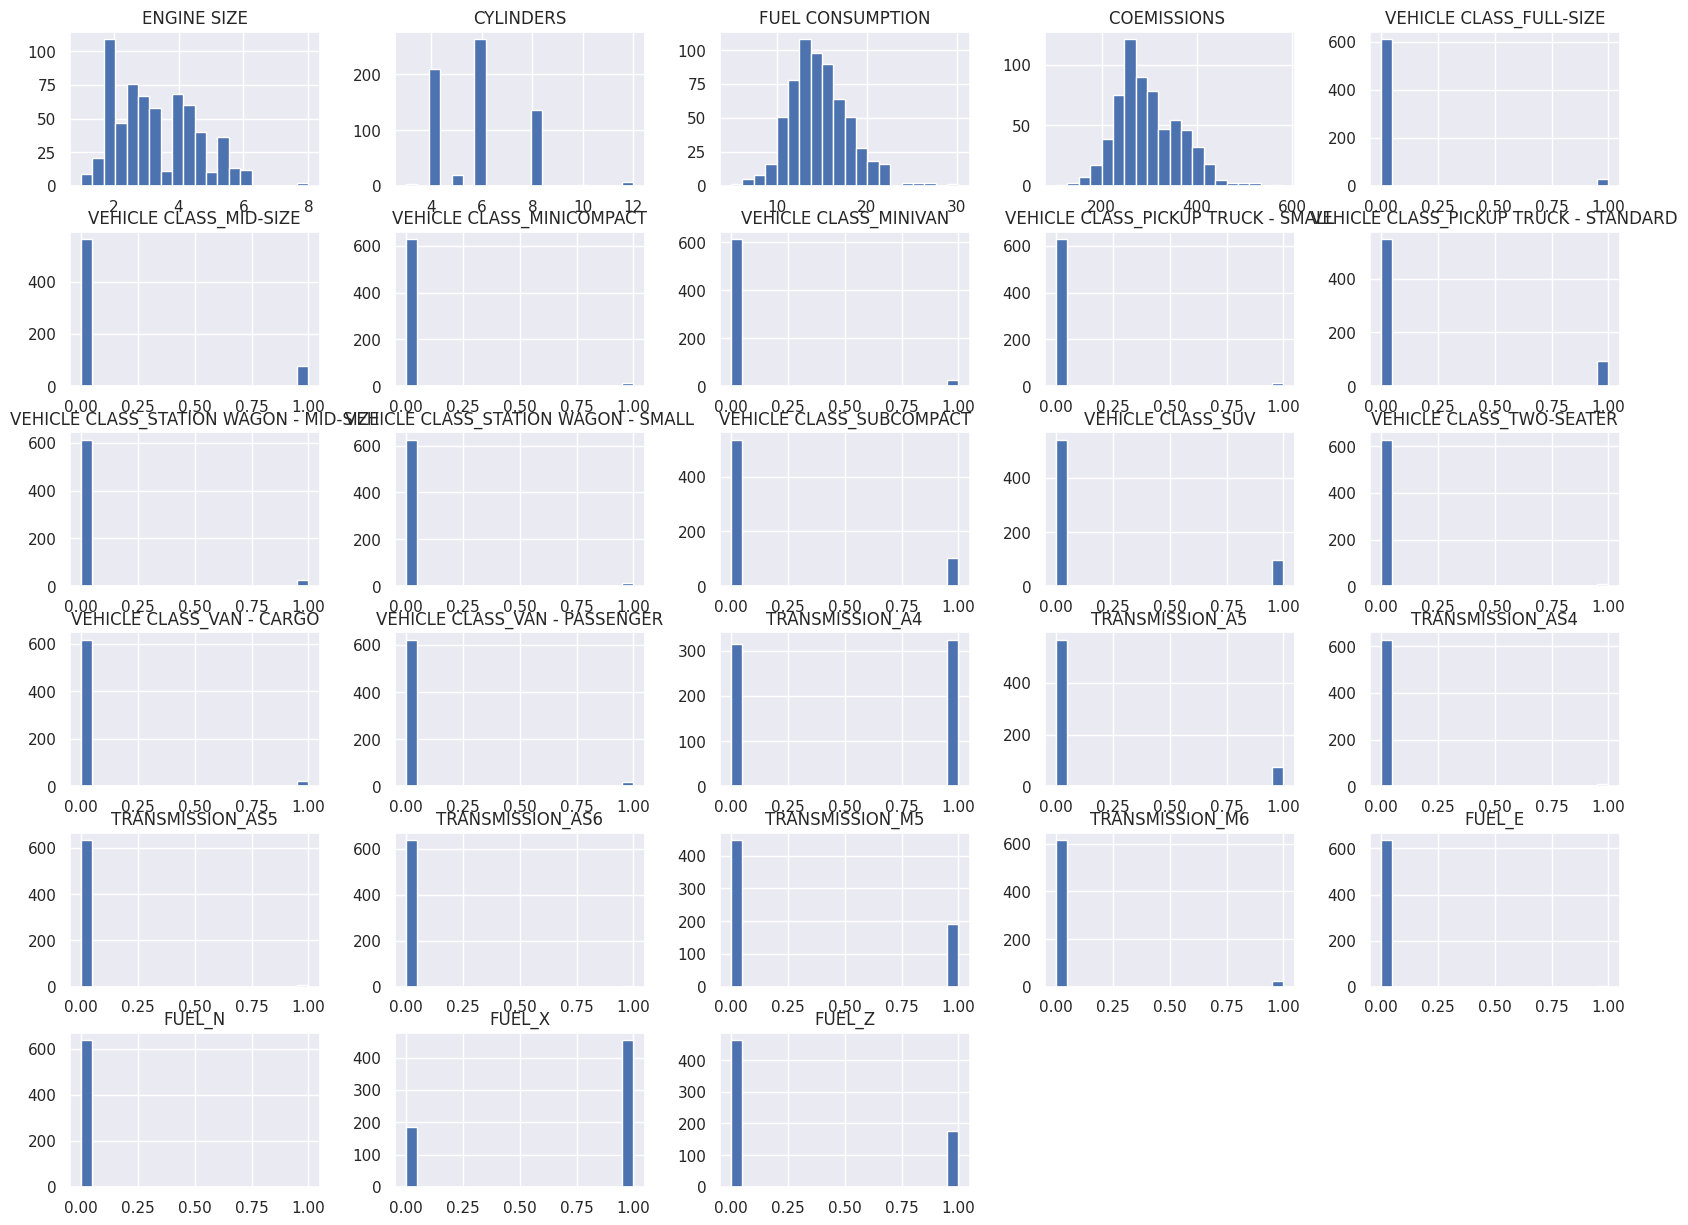

In [14]:
sns.set()
df_encoded.hist(bins=20,figsize=(20,15))
plt.show()

In [15]:
df_encoded.corr()

,ENGINE SIZE,CYLINDERS,FUEL CONSUMPTION,COEMISSIONS,VEHICLE CLASS_FULL-SIZE,VEHICLE CLASS_MID-SIZE,VEHICLE CLASS_MINICOMPACT,VEHICLE CLASS_MINIVAN,VEHICLE CLASS_PICKUP TRUCK - SMALL,VEHICLE CLASS_PICKUP TRUCK - STANDARD,...,TRANSMISSION_A5,TRANSMISSION_AS4,TRANSMISSION_AS5,TRANSMISSION_AS6,TRANSMISSION_M5,TRANSMISSION_M6,FUEL_E,FUEL_N,FUEL_X,FUEL_Z
ENGINE SIZE,1.000000,0.893819,0.858170,0.849714,0.077443,-0.070975,-0.000225,0.015398,-0.011963,0.314394,...,0.080798,-0.027075,-0.006189,0.010759,-0.313923,0.137204,0.001561,0.062257,-0.001796,0.019457
CYLINDERS,0.893819,1.000000,0.825784,0.798447,0.110298,0.008707,0.030626,0.024604,-0.073075,0.202679,...,0.209485,-0.011862,0.010609,0.053477,-0.336604,0.178251,0.006694,0.053477,-0.205844,0.226781
FUEL CONSUMPTION,0.858170,0.825784,1.000000,0.983232,-0.010368,-0.101321,0.007101,0.059798,-0.019479,0.329760,...,0.038568,-0.013130,0.017909,0.118448,-0.306119,0.164969,0.099815,0.072920,-0.029740,0.057780
COEMISSIONS,0.849714,0.798447,0.983232,1.000000,-0.039791,-0.129578,-0.005129,0.019480,-0.020202,0.373053,...,0.025250,-0.023903,0.003787,0.107177,-0.288439,0.129947,-0.011822,0.033988,0.024075,0.012021
VEHICLE CLASS_FULL-SIZE,0.077443,0.110298,-0.010368,-0.039791,1.000000,-0.079238,-0.028332,-0.044087,-0.028332,-0.087793,...,0.019258,0.195672,-0.019011,-0.008475,-0.123076,-0.041365,-0.011995,-0.008475,0.001794,0.004928
VEHICLE CLASS_MID-SIZE,-0.070975,0.008707,-0.101321,-0.129578,-0.079238,1.000000,-0.048988,-0.076231,-0.048988,-0.151802,...,0.214640,-0.015795,0.021687,-0.014654,-0.084173,-0.045717,-0.020741,-0.014654,-0.198283,0.212974
VEHICLE CLASS_MINICOMPACT,-0.000225,0.030626,0.007101,-0.005129,-0.028332,-0.048988,1.000000,-0.027257,-0.017516,-0.054277,...,0.103761,-0.018309,0.261349,-0.005240,-0.033851,0.168199,-0.007416,-0.005240,-0.207328,0.214660
VEHICLE CLASS_MINIVAN,0.015398,0.024604,0.059798,0.019480,-0.044087,-0.076231,-0.027257,1.000000,-0.027257,-0.084461,...,-0.073962,0.088214,-0.018289,-0.008154,-0.134473,-0.039795,0.272075,-0.008154,0.096536,-0.126976
VEHICLE CLASS_PICKUP TRUCK - SMALL,-0.011963,-0.073075,-0.019479,-0.020202,-0.028332,-0.048988,-0.017516,-0.027257,1.000000,-0.054277,...,-0.047530,-0.018309,-0.011753,-0.005240,0.044997,-0.025573,-0.007416,-0.005240,0.084484,-0.081599
VEHICLE CLASS_PICKUP TRUCK - STANDARD,0.314394,0.202679,0.329760,0.373053,-0.087793,-0.151802,-0.054277,-0.084461,-0.054277,1.000000,...,-0.091230,-0.056736,-0.036420,-0.016236,0.092516,-0.079245,-0.022980,-0.016236,0.261793,-0.252852


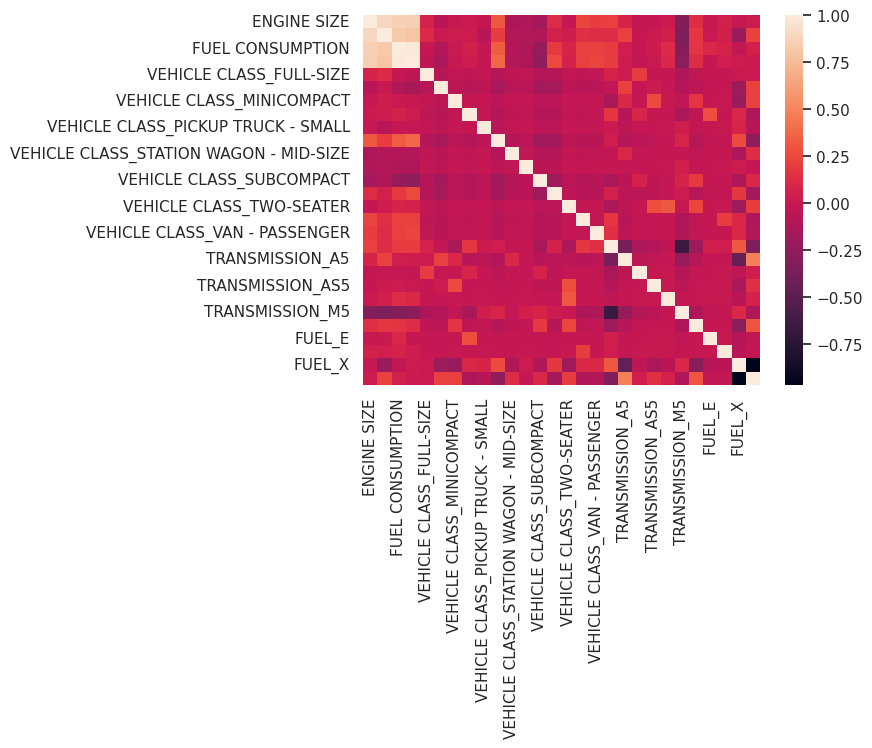

In [16]:
sns.heatmap(df_encoded.corr())
plt.show()

# Feature Engineering


In [17]:
df_encoded.columns

Index(['ENGINE SIZE', 'CYLINDERS', 'FUEL CONSUMPTION', 'COEMISSIONS ',
       'VEHICLE CLASS_FULL-SIZE', 'VEHICLE CLASS_MID-SIZE',
       'VEHICLE CLASS_MINICOMPACT', 'VEHICLE CLASS_MINIVAN',
       'VEHICLE CLASS_PICKUP TRUCK - SMALL',
       'VEHICLE CLASS_PICKUP TRUCK - STANDARD',
       'VEHICLE CLASS_STATION WAGON - MID-SIZE',
       'VEHICLE CLASS_STATION WAGON - SMALL', 'VEHICLE CLASS_SUBCOMPACT',
       'VEHICLE CLASS_SUV', 'VEHICLE CLASS_TWO-SEATER',
       'VEHICLE CLASS_VAN - CARGO', 'VEHICLE CLASS_VAN - PASSENGER',
       'TRANSMISSION_A4', 'TRANSMISSION_A5', 'TRANSMISSION_AS4',
       'TRANSMISSION_AS5', 'TRANSMISSION_AS6', 'TRANSMISSION_M5',
       'TRANSMISSION_M6', 'FUEL_E', 'FUEL_N', 'FUEL_X', 'FUEL_Z'],
      dtype='object')

In [18]:
X = df_encoded.drop('COEMISSIONS ', axis=1)
y = df_encoded['COEMISSIONS ']

In [19]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape



((479, 27), (160, 27), (479,), (160,))

feature standardization

In [20]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


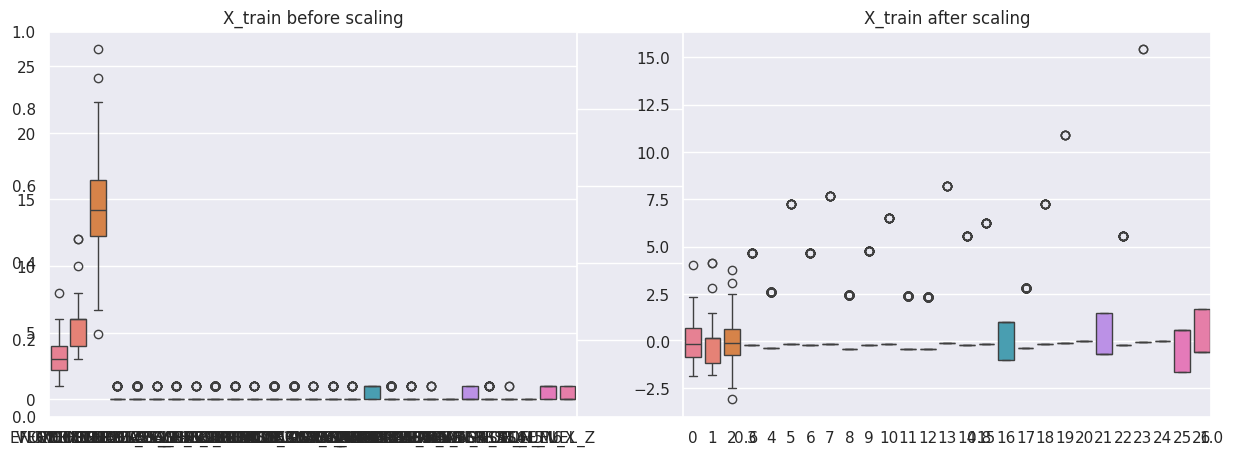

In [21]:
#Box plot to understand the effects of standard scaler
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title('X_train before scaling')
plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title('X_train after scaling')
plt.show()

# Model Training

MAE: 5.131831073044773
R2 score: 0.9821305758413905
MSE: 91.20732505586116
RMSE: 9.550252617384587


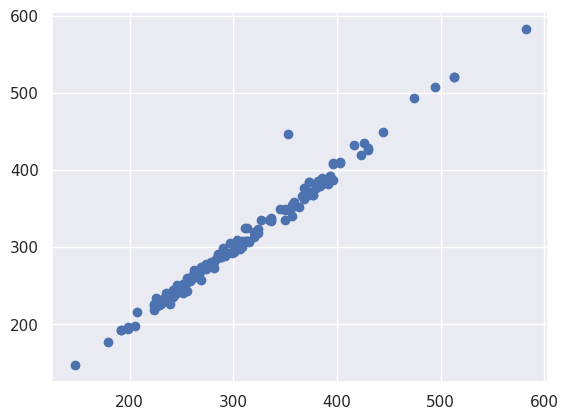

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error
model=LinearRegression()
model.fit(X_train_scaled,y_train)
y_pred=model.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
r2score=r2_score(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
print('MAE:',mae)
print('R2 score:',r2score)
print('MSE:',mse)
print('RMSE:',rmse)
plt.scatter(y_test,y_pred)
plt.show()

# Apply Ridge,Lasso and Elastic Net regression

MAE: 5.593802496434902
R2 score: 0.986169528094147
MSE: 70.59210949365277
RMSE: 8.40191106199374


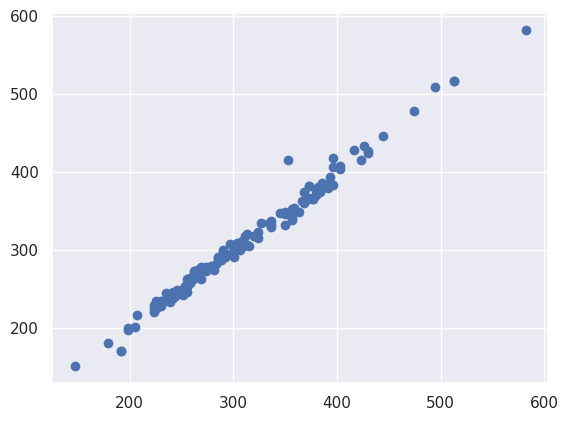

In [23]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error
lasso_model=Lasso()
lasso_model.fit(X_train_scaled,y_train)
y_pred=lasso_model.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
r2score=r2_score(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
print('MAE:',mae)
print('R2 score:',r2score)
print('MSE:',mse)
print('RMSE:',rmse)
plt.scatter(y_test,y_pred)
plt.show()

MAE: 5.069194847067685
R2 score: 0.9833472175533903
MSE: 84.99746428374364
RMSE: 9.219406937745163


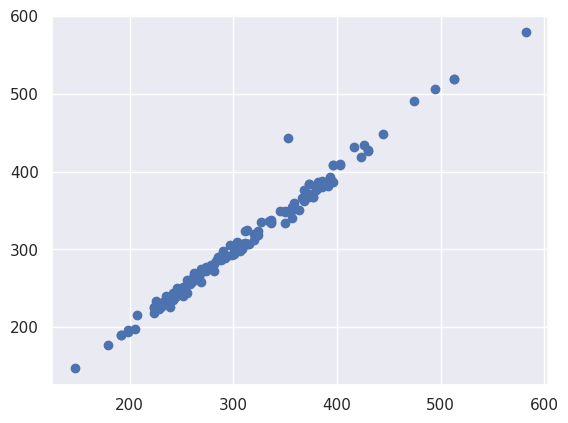

In [24]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error
ridge_model=Ridge()
ridge_model.fit(X_train_scaled,y_train)
y_pred=ridge_model.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
r2score=r2_score(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
print('MAE:',mae)
print('R2 score:',r2score)
print('MSE:',mse)
print('RMSE:',rmse)
plt.scatter(y_test,y_pred)
plt.show()

MAE: 14.446745008482683
R2 score: 0.9065606414150289
MSE: 476.92381555365154
RMSE: 21.838585475109223


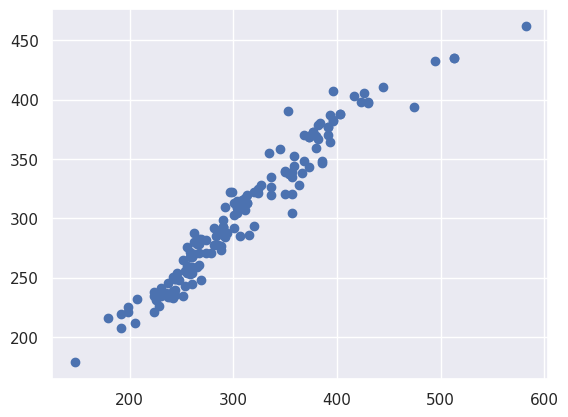

In [25]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error
elasticnet=ElasticNet()
elasticnet.fit(X_train_scaled,y_train)
y_pred=elasticnet.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
r2score=r2_score(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
print('MAE:',mae)
print('R2 score:',r2score)
print('MSE:',mse)
print('RMSE:',rmse)
plt.scatter(y_test,y_pred)
plt.show()

# Cross Validation